In [1]:
from xarray import Dataset
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [18]:
#path
Precipitation_path=r'D:/KAUST/semster2/geo_env_modelling/assignmnet7/OneDrive_1_2026-3-11/Precipitation/'
evaporation_path=r'D:/KAUST/semster2/geo_env_modelling/assignmnet7/OneDrive_1_2026-3-11/Total_evaporation/'
runoff_path=r'D:/KAUST/semster2/geo_env_modelling/assignmnet7/OneDrive_1_2026-3-11/Runoff/'

In [6]:
#open files
ds = xr.open_mfdataset(Precipitation_path + '*.nc', combine='by_coords')

In [11]:
print(ds.variables.keys())
ds.close()

KeysView(Frozen({'tp': <xarray.Variable (valid_time: 184104, latitude: 69, longitude: 89)> Size: 5GB
dask.array<concatenate, shape=(184104, 69, 89), dtype=float32, chunksize=(2928, 23, 30), chunktype=numpy.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      6141
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown
    GRIB_surface:                             0.0, 'number': <xarray.Variable ()> Size: 8B
array(0)
Attributes:
    long_name:      ensemble member

In [14]:
ds

<xarray.Dataset> Size: 5GB
Dimensions:     (valid_time: 184104, latitude: 69, longitude: 89)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1MB 2000-01-01 ... 2020-12-31T23:...
  * latitude    (latitude) float64 552B 33.0 32.75 32.5 ... 16.5 16.25 16.0
  * longitude   (longitude) float64 712B 34.0 34.25 34.5 ... 55.5 55.75 56.0
    number      int64 8B 0
    expver      (valid_time) <U4 3MB dask.array<chunksize=(8784,), meta=np.ndarray>
Data variables:
    tp          (valid_time, latitude, longitude) float32 5GB dask.array<chunksize=(2928, 23, 30), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-03-08T11:46 GRIB to CDM+CF via cfgrib-0.9.1...

In [14]:
# Resample to monthly sum
monthly_precip = ds.tp.resample(valid_time='ME').sum()
monthly_precip_mean = monthly_precip.mean(dim=['latitude', 'longitude'])

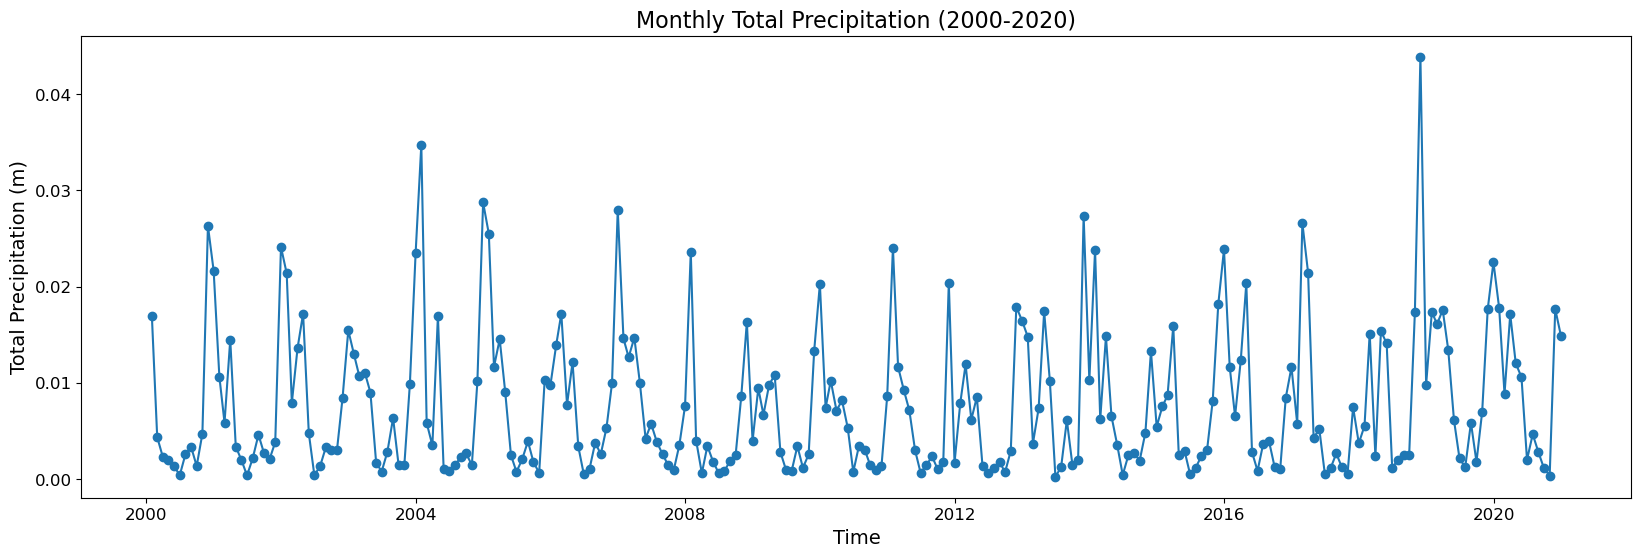

In [23]:
# Plot total precipitation against time
plt.figure(figsize=(20, 6))
plt.plot(monthly_precip_mean.valid_time, monthly_precip_mean, marker='o')
plt.title('Monthly Total Precipitation (2000-2020)', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Total Precipitation (m)', fontsize=14)
plt.show()

Total evaporation

In [24]:
ds_evap = xr.open_mfdataset(evaporation_path + '*.nc', combine='by_coords')

# Resample to monthly sum
monthly_evap = ds_evap.e.resample(valid_time='ME').sum()
monthly_evap_mean = monthly_evap.mean(dim=['latitude', 'longitude'])

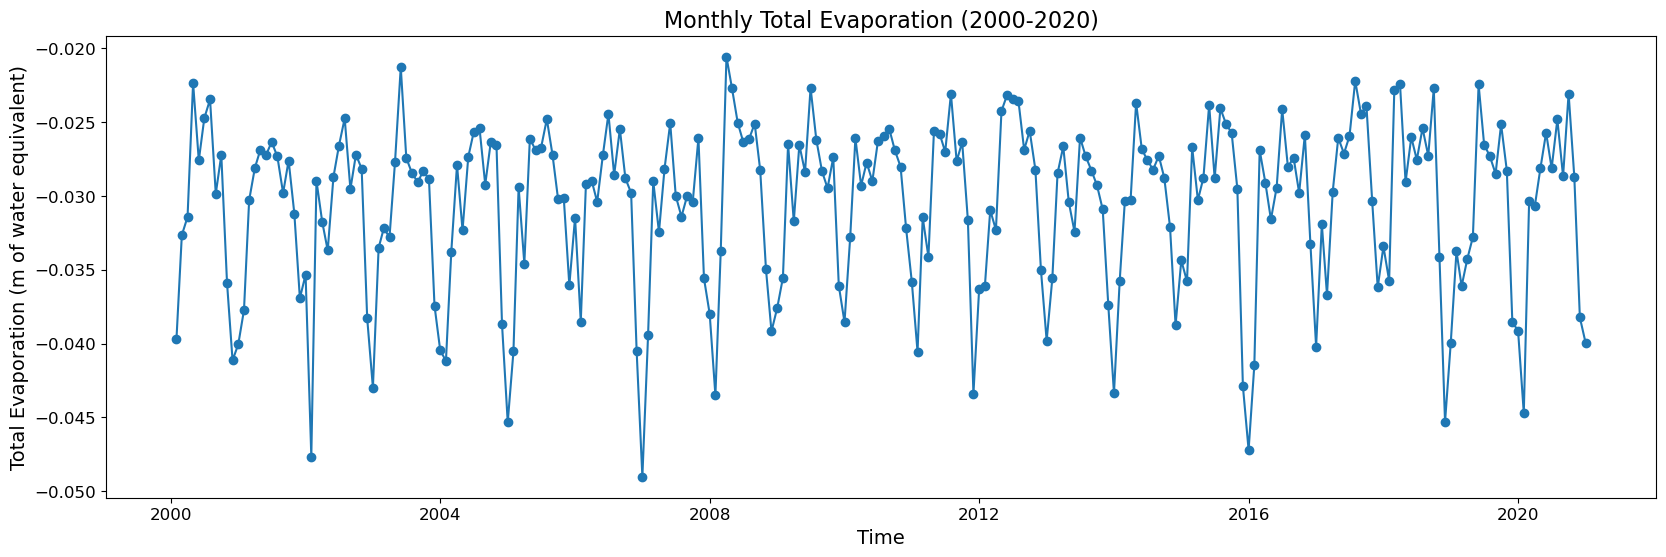

In [17]:
# Plot total precipitation against time
plt.figure(figsize=(20, 6))
plt.plot(monthly_evap_mean.valid_time, monthly_evap_mean, marker='o')
plt.title('Monthly Total Evaporation (2000-2020)', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Total Evaporation (m of water equivalent)', fontsize=14)
plt.show()

Runoff

In [25]:
ds_runoff = xr.open_mfdataset(runoff_path + '*.nc', combine='by_coords')

# Resample to monthly sum
monthly_runoff = ds_runoff.ro.resample(valid_time='ME').sum()
monthly_runoff_mean = monthly_runoff.mean(dim=['latitude', 'longitude'])

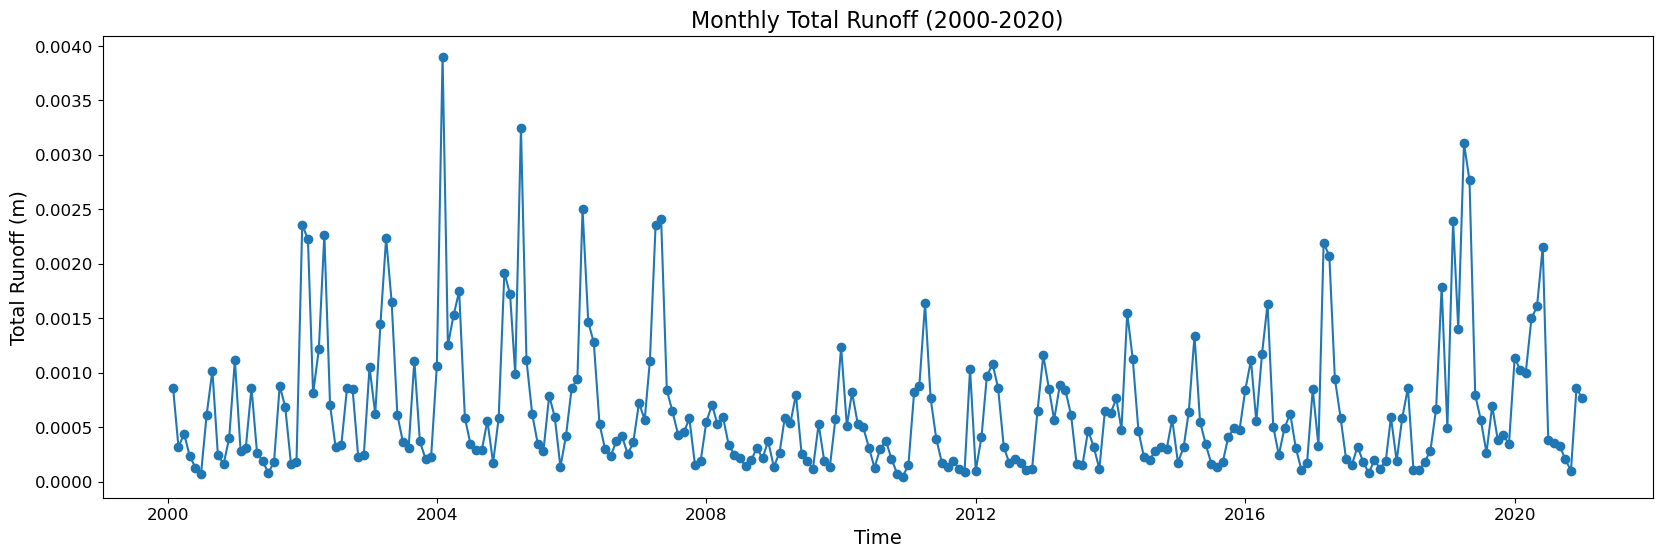

In [30]:
# Plot total precipitation against time
plt.figure(figsize=(20, 6))
plt.plot(monthly_runoff_mean.valid_time, monthly_runoff_mean, marker='o')

plt.title('Monthly Total Runoff (2000-2020)', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Total Runoff (m)', fontsize=14)

plt.show()

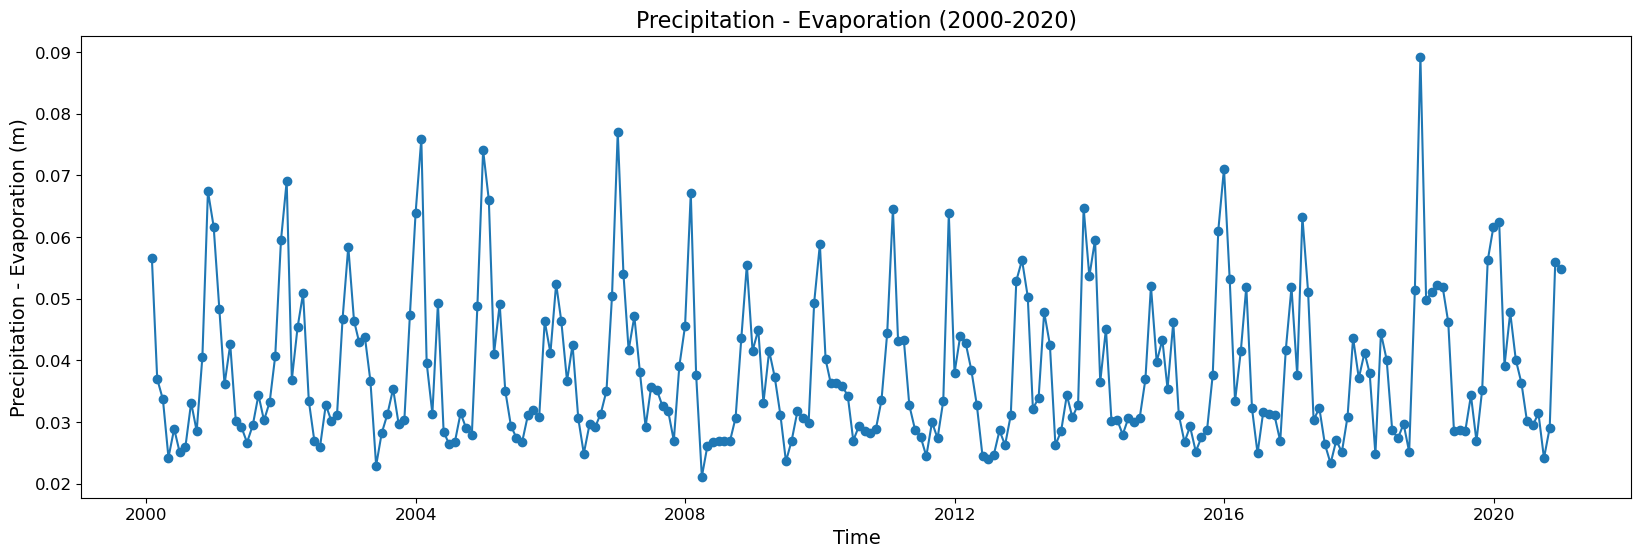

In [32]:
# Calculate precipitation - evaporation
precip_minus_evap = monthly_precip_mean - monthly_evap_mean

# Plot the time series
plt.figure(figsize=(20, 6))
plt.plot(precip_minus_evap.valid_time, precip_minus_evap, marker='o')
plt.title('Precipitation - Evaporation (2000-2020)', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Precipitation - Evaporation (m)', fontsize=14)
plt.show()

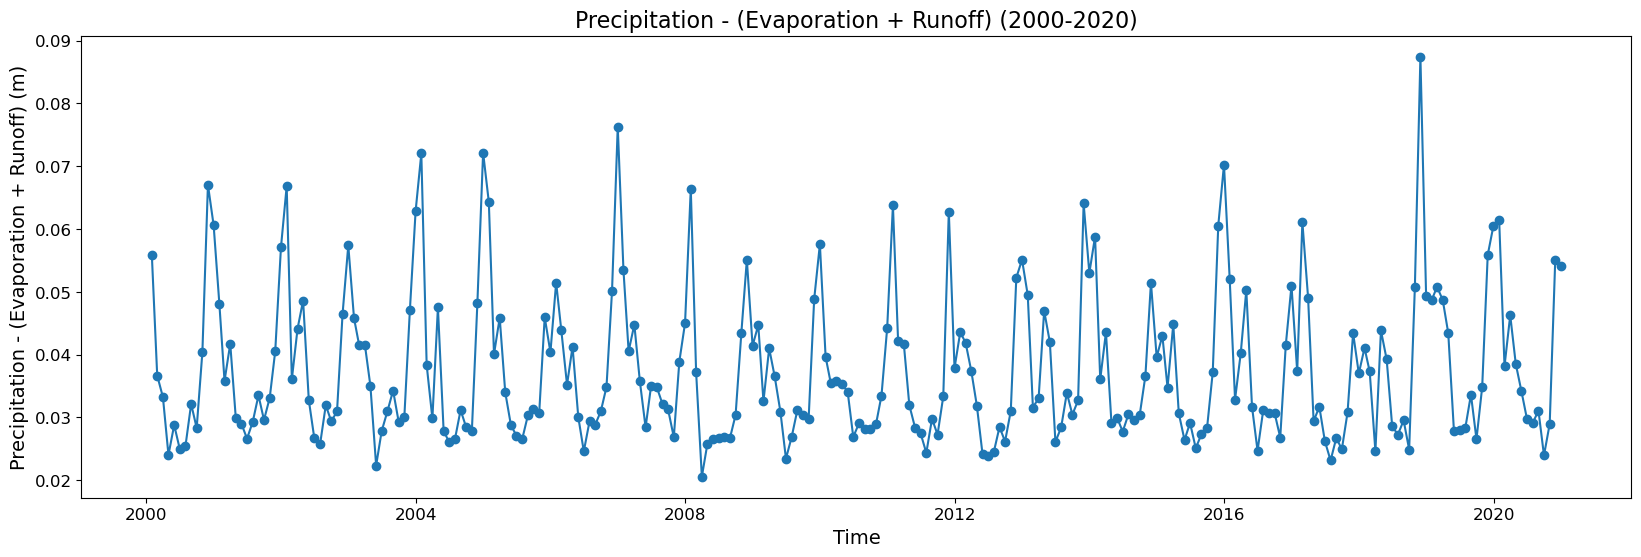

In [35]:
# Calculate Precipitation - (Evaporation + Runoff)
precip_minus_evap_runoff = monthly_precip_mean - (monthly_evap_mean + monthly_runoff_mean)

# Plot the time series
plt.figure(figsize=(20, 6))
plt.plot(precip_minus_evap_runoff.valid_time, precip_minus_evap_runoff, marker='o')
plt.title('Precipitation - (Evaporation + Runoff) (2000-2020)', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Precipitation - (Evaporation + Runoff) (m)', fontsize=14)
plt.show()